In [95]:
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import contextily as ctx
from rasterio.io import MemoryFile

In [96]:
# Path to your GeoTIFF
era5_tif_path = "../../ERA5_daily_Uttarakhand/ERA5_daily_2020-06-01.tif"
chirps_tif_path = "../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2020-06-01.tif"

BAND_TO_PLOT = 5      # 1-indexed band number
MARGIN_FRAC = 0.1     # fraction of extent for surrounding map
RASTER_ALPHA = 0.6    # transparency of the raster layer

In [97]:
"ERA5".startswith("ERA5")

True

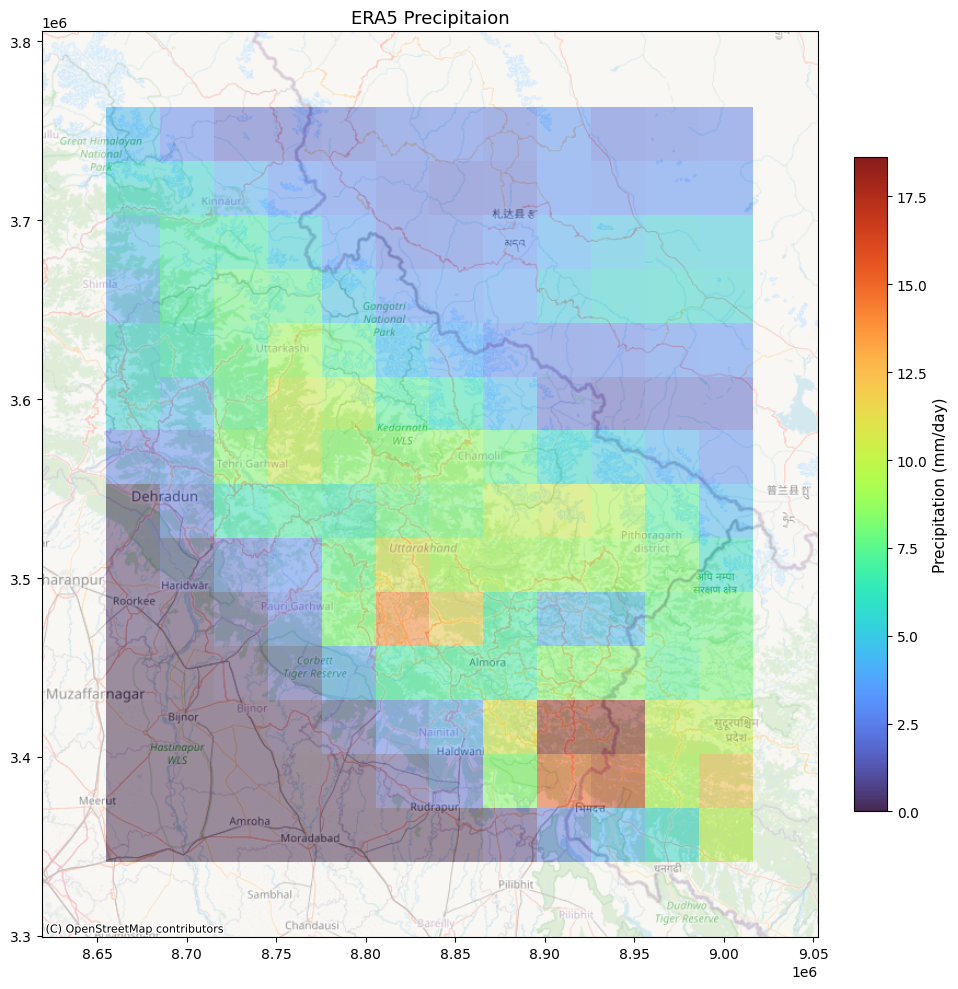

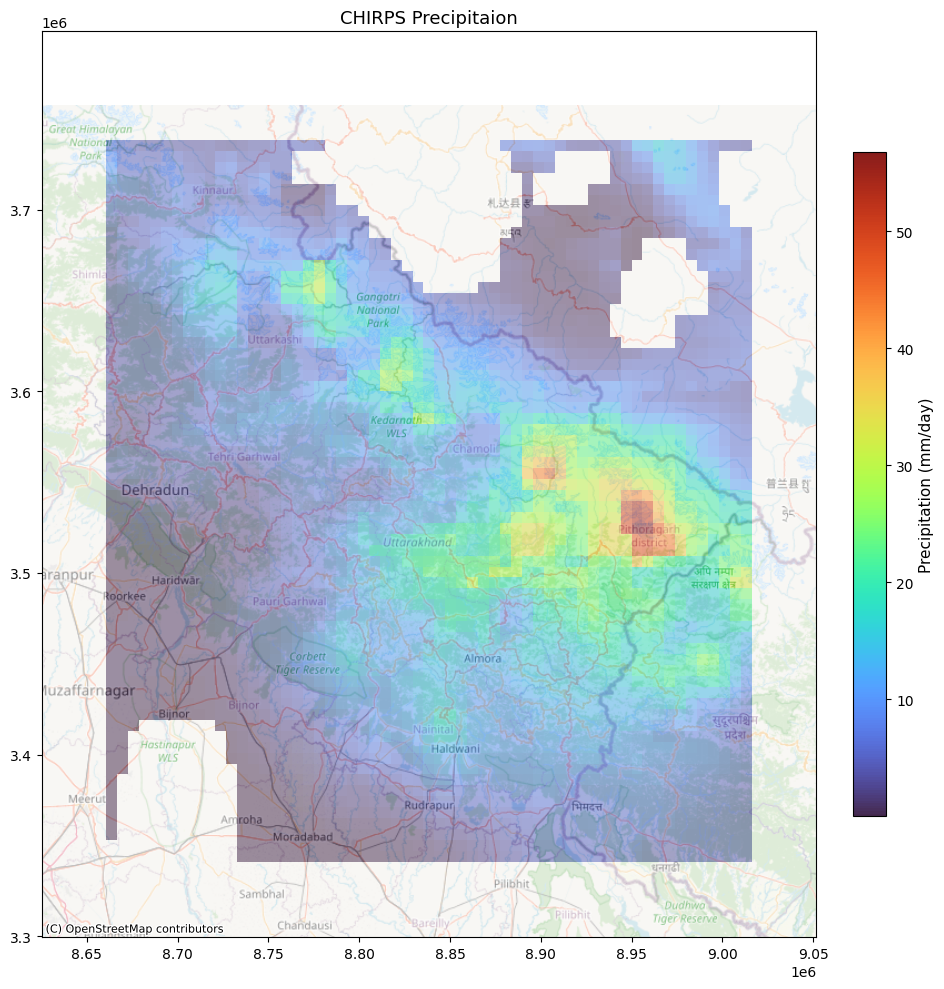

In [98]:
def plot_data(tif_path, label, band_to_plot):
    with rasterio.open(tif_path) as src:
        if band_to_plot > src.count:
            raise ValueError(f"Band {band_to_plot} not found. Raster only has {src.count} bands.")

        if label.startswith("ERA5"):
            band_data = src.read(band_to_plot).astype(float)*1000 # Convert to mm/day
        else:
            band_data = src.read(band_to_plot).astype(float)
        if src.nodata is not None:
            band_data[band_data == src.nodata] = np.nan

        if src.crs != "EPSG:3857":
            transform, width, height = calculate_default_transform(
                src.crs, "EPSG:3857", src.width, src.height, *src.bounds
            )

            kwargs = src.meta.copy()
            kwargs.update({
                "count": 1,
                "crs": "EPSG:3857",
                "transform": transform,
                "width": width,
                "height": height
            })

            memfile = MemoryFile()
            with memfile.open(**kwargs) as dst:
                reproject(
                    source=band_data,
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs="EPSG:3857",
                    resampling=Resampling.bilinear
                )

            with memfile.open() as dataset:
                data = dataset.read(1)
                data[data == dataset.nodata] = np.nan

                vmin, vmax = np.nanpercentile(data, [2, 98])
                xmin, ymin, xmax, ymax = dataset.bounds

                # Add margin for context
                x_margin = (xmax - xmin) * MARGIN_FRAC
                y_margin = (ymax - ymin) * MARGIN_FRAC
                xmin, xmax = xmin - x_margin, xmax + x_margin
                ymin, ymax = ymin - y_margin, ymax + y_margin

                # --- PLOT ---
                fig, ax = plt.subplots(figsize=(10, 10))
                im = show(data, transform=dataset.transform, ax=ax,
                        cmap='turbo', alpha=0.9)
                
                # Add basemap BELOW raster
                ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)

                # Square axis and limits
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_aspect('equal', adjustable='box')

                # Add colorbar beside the map
                cbar = plt.colorbar(im.get_images()[0], ax=ax, orientation='vertical',
                                    fraction=0.036, pad=0.04)
                cbar.set_label("Precipitation (mm/day)", fontsize=11)

                ax.set_title(label, fontsize=13)
                plt.tight_layout()
                plt.show()

        else:
            # Already in EPSG:3857
            vmin, vmax = np.nanpercentile(band_data, [2, 98])
            xmin, ymin, xmax, ymax = src.bounds
            x_margin = (xmax - xmin) * MARGIN_FRAC
            y_margin = (ymax - ymin) * MARGIN_FRAC
            xmin, xmax = xmin - x_margin, xmax + x_margin
            ymin, ymax = ymin - y_margin, ymax + y_margin

            fig, ax = plt.subplots(figsize=(10, 10))
            im = show(band_data, transform=src.transform, ax=ax,
                    cmap='turbo', vmin=vmin, vmax=vmax)
            ctx.add_basemap(ax, crs=src.crs.to_string(),
                            source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.4)
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_aspect('equal', adjustable='box')

            cbar = plt.colorbar(im.get_images()[0], ax=ax, orientation='vertical',
                                fraction=0.036, pad=0.04)
            cbar.set_label("Precipitation (mm/day)", fontsize=11)

            ax.set_title(label, fontsize=13)
            plt.tight_layout()
            plt.show()

plot_data(era5_tif_path, "ERA5 Precipitaion", band_to_plot=5)
plot_data(chirps_tif_path, "CHIRPS Precipitaion", band_to_plot=1)